# Rural Fire Dataset – Explainable Artificial Intelligence (XAI) Project

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022), Nuno Moreira (202104873) and Pedro Silva (202205150).

## Table of Contents

1. [Introduction](#introduction)  

2. [Pre-Modelling](#pre-modelling)  
   - 2.1. [Dataset Description](#dataset-description)  
   - 2.2. [Data Preprocessing](#data-preprocessing)  
     - 2.2.1. [Type Standardization and NA Handling](#221-type-standardization-and-na-handling)  
     - 2.2.2. [Timestamp Reconstruction from Excel Serials](#222-timestamp-reconstruction-from-excel-serials)  
     - 2.2.3. [Fire Duration Calculation and Validation](#223-fire-duration-calculation-and-validation)  
     - 2.2.4. [Area Consistency and Completeness Filter](#224-area-consistency-and-completeness-filter)  
     - 2.2.5. [Temporal Feature Extraction](#225-temporal-feature-extraction)  
     - 2.2.6. [Missing Data Summary](#226-missing-data-summary)  
     - 2.2.7. [Numeric Consistency](#227-numeric-consistency)  
     - 2.2.8. [Area Consistency](#228-area-consistency)  
     - 2.2.9. [Inspection of Inconsistent Area Record](#229-inspection-of-inconsistent-area-record)  
     - 2.2.10. [Temporal Coherence Validation](#2210-temporal-coherence-validation)  
     - 2.2.11. [Administrative Division Consistency](#2211-administrative-division-consistency)  
     - 2.2.12. [Categorical Variable Identification](#2212-categorical-variable-identification)  
     - 2.2.13. [Conversion to Categorical Data Type](#2213-conversion-to-categorical-data-type)
     - 2.2.14. [Label Integrity](#2214-label-integrity)
     - 2.2.15. [Distribution of Fire Causes in Portugal (1980–2005, Excluding “Unknown”)](#2215-distribution-of-fire-causes-in-portugal-19802005-excluding-unknown)
     - 2.2.16. [Label Mapping](#2216-label-maping)
     - 2.2.17. [Numeric Feature Scaling](#2217-numeric-feature-scaling)
   - 2.3. [Data Understanding and Descriptive Analysis](#data-understanding-and-descriptive-analysis)
     - 2.3.1. [Temporal Analysis](#231-temporal-analysis)
     - 2.3.2. [Monthly Patterns](#232-monthly-patterns)
     - 2.3.3. [Duration Distribution](#233-duration-distribution)
     - 2.3.4. [Spatial Analysis](#234-spatial-analysis)
     - 2.3.5. [Spatial Distribution of Fire Incidents by District (1980–2005)](#235-spatial-distribution-of-fire-incidents-by-district-19802005)
     - 2.3.6. [Comparison Between Fire Frequency and Total Burned Area by District (1980–2005)](#236-comparison-between-fire-frequency-and-total-burned-area-by-district-19802005)
     - 2.3.7. [Land Cover Composition](#237-land-cover-composition)
     - 2.3.8. [Fire Size Categories](#238-fire-size-categories)
     - 2.3.9. [Correlation Matrix](#239-correlation-matrix)
     - 2.3.10. [Derived Ratios](#2310-derived-ratios)
     - 2.3.11. [Suspicious Records Visualization](#2311-suspicious-records-visualization)
              

3. [In-Modelling](#in-modelling)  
   - 3.1. [In-Modeling Approaches to Explainable AI](#31-in-modeling-approaches-to-explainable-ai)
   - 3.2. [Pre-processing before training the model](#32-pre-processing-before-training-the-model)
     - 3.2.1. [Verify missing values](#321-verify-missing-values)
     - 3.2.2. [Geographic Hierarchy and Model Limitations](#322-geographic-hierarchy-and-model-limitations)
     - 3.2.3. [SMOTE usage to combat miss classification](#323-smote-usage-to-combat-miss-classification)
   - 3.3. [Glass Model Training](#33-glass-model-training)
     - 3.3.1. [Logistic Regression](#331-logistic-regression)
       - 3.3.1a. [Logistic Regression using Districts and Counties](#331a-logistic-regression-using-districts-and-counties)
       - 3.3.1b. [Logistic Regression using only Districts](#331b-logistic-regression-using-only-districts)
       - 3.3.1c. [Logistic Regression using only Counties](#331c-logistic-regression-using-only-counties)
     - 3.3.2. [Decision Tree](#332-decision-tree)
       - 3.3.2a. [Decision Tree — Districts + Counties](#332a-decision-tree--districts--counties)
       - 3.3.2b. [Decision Tree — Only Counties](#332b-decision-tree--only-counties)
      - 3.3.3. [Rule-Based Learners](#333-rule-based-learners)
        - 3.3.3a. [RuleFit Model (Districts + Counties)](#333a-rulefit-model-districts--counties)
        - 3.3.3b. [RuleFit Model (Only Counties)](#333b-rulefit-model-only-counties)
      - 3.3.4. [Bayesian Rule List Model](#334-bayesian-rule-list-model)
        - 3.3.4a. [BRL using Districts and Counties](#334a-brl-using-districts-and-counties)
        - 3.3.4b. [BRL using Counties Only](#334b-brl-using-counties-only)
- 4. [Post-Modelling](#post-modelling)
  - 4.1. [Explainability Techniques](#41-explainability-techniques)
  - 4.2. [Black-Box Model Training](#42-black-box-model-training)
    - 4.2.1. [XGBoost](#421-xgboost)
    - 4.2.2. [Random Forest](#422-random-forest)
    - 4.2.3. [Neural Network](#423-neural-network)
  - 4.3. [Simplification-Based Explanation (Task 3.1)](#43-simplification-based-explanation)
  - 4.3.1. [Global Surrogate Model](#431-global-surrogate-model)
    - 4.3.1a. [CART Decision Tree](#431a-cart-decision-tree)
    - 4.3.1b. [Fidelity Evaluation and Feature Importance](#431b-fidelity-evaluation-and-feature-importance)

   - 4.4. [Feature-Based Explanations (Task 3.2)](#44-feature-based-explanations)
     - 4.4.1. [Sensitivity Analysis (PDP / ICE / c-ICE)](#441-sensitivity-analysis)
     - 4.4.2. [Permutation and LOFO Importance](#442-feature-importance)
     - 4.4.3. [LIME (Local Interpretable Model-Agnostic Explanations)](#443-local-interpretable-model-agnostic-explanations-lime)
     - 4.4.4. [SHAP (SHapley Additive Explanations)](#444-shapley-additive-explanations-shap)
   - 4.5. [Example-Based Explanations (Task 3.3)](#45-example-based-explanations)
     


5. [Results and Visualization](#results-and-visualization)  

6. [Conclusions and Future Work](#conclusions-and-future-work)


## 4. Post-Modelling
[[go back to top]](#table-of-contents)

This section focuses on **post-hoc explainability techniques**, which are applied *after* the training of a black-box model.  

While pre-modelling and in-modelling approaches aim to build interpretable models from the start, post-modelling methods seek to **understand or approximate the behavior** of complex models that are already trained.  

According to the XAI taxonomy presented in the lectures, post-hoc methods can be grouped into three main categories:  
1. **Simplification-based techniques** — build a simpler surrogate model (e.g., decision tree or linear model) that mimics the black-box behavior.  
2. **Feature-based techniques** — analyze how individual input features influence model predictions (e.g., PDP, ICE, PFI).  
3. **Example-based techniques** — explain individual predictions through concrete instances (e.g., LIME, SHAP, counterfactuals).  

The following subsections implement and compare these approaches on the trained models to assess both **global** and **local** interpretability.

### 4.1 – Explainability Techniques  
[[go back to the topic]](#4-post-modelling)

Explainability techniques aim to make the internal logic of a predictive model more understandable.  
Within the XAI taxonomy, **post-hoc methods** are applied after training a model to interpret or approximate its behavior without altering it.  

These methods can provide explanations at different levels:
- **Global** → understanding how the model behaves overall.  
- **Feature-level** → understanding which features drive predictions.  
- **Local** → explaining individual decisions.

The next sections apply these three complementary approaches — simplification-based, feature-based, and example-based — to the previously trained black-box models.



In [351]:
!pip install xgboost tqdm

### 4.2. Black box Model Training
[[go back to the topic]](#4-post-modelling)

In this part of the notebook the black models choosed will be trained, only after being trained the XAI techniques will be applied

#### 4.2.1. XGBoost
[[go back to the topic]](#42-black-box-model-training)


C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
Training XGBoost: 100%|████████████████████████████████| 199/199 [00:04<00:00, 44.95round/s, train=0.1860, test=0.2778]


=== XGBoost Classifier (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.9536    0.8527    0.9003      7564
           1     0.6941    0.8895    0.7798      2842

    accuracy                         0.8628     10406
   macro avg     0.8239    0.8711    0.8401     10406
weighted avg     0.8827    0.8628    0.8674     10406



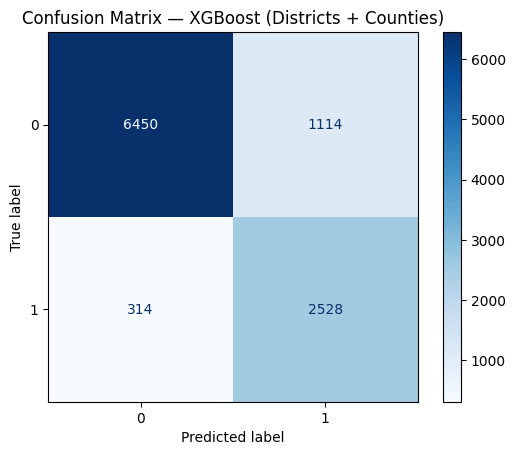

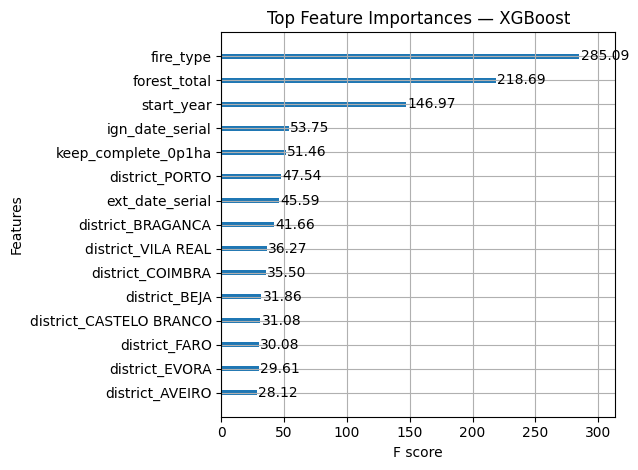


=== XGBoost Feature Importances ===
                                 gain
fire_type                  285.089966
forest_total               218.686951
start_year                 146.968246
ign_date_serial             53.752079
keep_complete_0p1ha         51.463032
district_PORTO              47.539925
ext_date_serial             45.585426
district_BRAGANCA           41.664585
district_VILA REAL          36.269459
district_COIMBRA            35.495388
district_BEJA               31.856895
district_CASTELO BRANCO     31.083603
district_FARO               30.081652
district_EVORA              29.606735
district_AVEIRO             28.116577
district_VISEU              27.414305
district_SETUBAL            25.586393
district_PORTALEGRE         23.639328
district_BRAGA              22.260452
district_VIANA DO CASTELO   21.073250
shrub_total                 21.034639
district_GUARDA             19.596672
district_LISBOA             18.942188
district_LEIRIA             18.777018
district_SANT

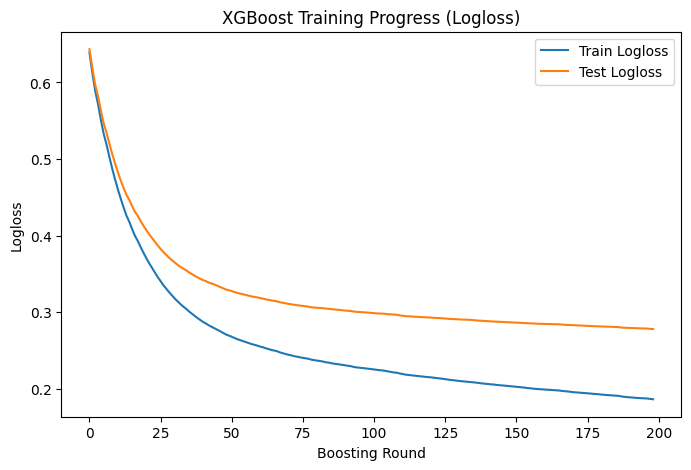

In [352]:
# === XGBoost Model (Districts + Counties) ===
# ----------------------------------------------------------
# Includes:
# - boolean → int conversion (so XGBoost uses all features)
# - full feature preservation (categories, districts, flags)
# - proper preprocessing pipeline with imputation
# - correct incremental XGBoost training with tqdm progress bar
# ----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

# === 1. Prepare data ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Convert boolean columns to integers (makes them numeric features)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Apply SMOTE to training data
X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Identify all numeric features (ints, floats, converted booleans)
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# === 2. Preprocessing ===
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Apply preprocessing to numeric columns only
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='passthrough'
)

# === 3. Transform data for XGBoost ===
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)


# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_proc, label=y_train)
dtest = xgb.DMatrix(X_test_proc, label=y_test)

# === XGBoost Parameters ===
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': 42,
}

num_rounds = 200

# === 4. Correct incremental training with tqdm ===
# Initialize booster with 1 initial round (required to set num_feature)
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1
)

train_losses = []
test_losses = []

progress = tqdm(range(1, num_rounds), desc="Training XGBoost", unit="round")

for i in progress:
    # Incrementally add one boosting round
    bst.update(dtrain, i)

    # Predictions
    pred_train = bst.predict(dtrain)
    pred_test = bst.predict(dtest)

    # Manual logloss computation
    eps = 1e-9
    train_loss = np.mean(
        -y_train * np.log(pred_train + eps) -
        (1 - y_train) * np.log(1 - pred_train + eps)
    )
    test_loss = np.mean(
        -y_test * np.log(pred_test + eps) -
        (1 - y_test) * np.log(1 - pred_test + eps)
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    progress.set_postfix({
        "train": f"{train_loss:.4f}",
        "test": f"{test_loss:.4f}"
    })

# === 5. Evaluate final model ===
y_pred_prob = bst.predict(dtest)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=== XGBoost Classifier (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — XGBoost (Districts + Counties)")
plt.show()

# === 6. Feature importance ===
feature_names = numeric_cols
bst.feature_names = feature_names

ax = xgb.plot_importance(
    bst,
    importance_type='gain',
    max_num_features=15
)

# --- Round the bar labels text (the numbers at the end of each bar) ---
for child in ax.get_children():
    if isinstance(child, plt.Text):          # only text elements
        txt = child.get_text()
        try:
            num = float(txt)
            child.set_text(f"{num:.2f}")     # round to 2 decimals
        except ValueError:
            pass

plt.title("Top Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

# Map feature importances to real names
importance_dict = bst.get_score(importance_type='gain')

importance_named = (
    pd.DataFrame.from_dict(importance_dict, orient='index', columns=['gain'])
      .sort_values(by='gain', ascending=False)
)

print("\n=== XGBoost Feature Importances ===")
print(importance_named.head(30))

# === Final losses ===
print(f"\nFinal Train Logloss: {train_losses[-1]:.4f}")
print(f"Final Test Logloss:  {test_losses[-1]:.4f}")

# === Loss curves ===
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Logloss')
plt.plot(test_losses, label='Test Logloss')
plt.xlabel('Boosting Round')
plt.ylabel('Logloss')
plt.title('XGBoost Training Progress (Logloss)')
plt.legend()
plt.show()


**Note on XGBoost Feature Importance:**

XGBoost provides feature importance metrics, but because it is a black-box model, these values are not reliable explanations of how predictions are made. They reflect internal training statistics rather than true model reasoning, so they should be seen as rough diagnostics rather than faithful interpretability. For actual explanatory purposes, model-agnostic methods such as SHAP or LIME are required.


#### 4.2.2. Random Forest 
[[go back to the topic]](#42-black-box-model-training)

C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Anaconda\envs\trabalho_labsiacd\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
Training Random Forest: 100%|██████████████████████████████████████████████████████| 300/300 [00:11<00:00, 26.03tree/s]


=== Random Forest Classifier (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.9692    0.8068    0.8806      7564
           1     0.6444    0.9317    0.7619      2842

    accuracy                         0.8410     10406
   macro avg     0.8068    0.8693    0.8213     10406
weighted avg     0.8805    0.8410    0.8482     10406



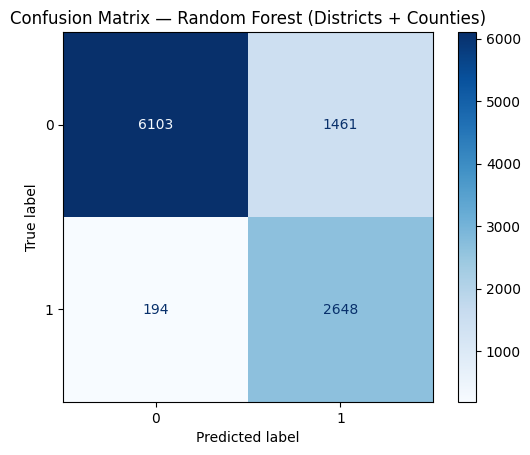

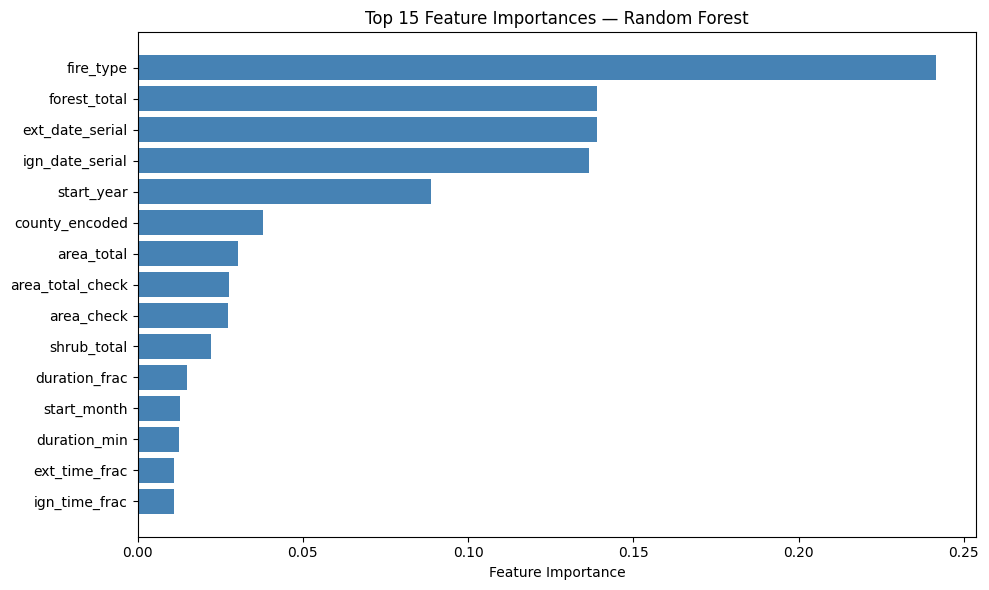

OOB Loss: 0.1108
Final Test Log Loss: 0.3142


In [353]:
# === Random Forest Model (Districts + Counties) ===
# ----------------------------------------------------------
# Includes:
# - Preprocessing (imputation)
# - Training with tqdm progress bar
# - Evaluation metrics and confusion matrix visualization
# ----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from tqdm import tqdm
import matplotlib.pyplot as plt

# === 1. Prepare data ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# === 2. Preprocessing ===
# Use median imputation for missing numeric values
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Apply transformations only to numeric columns
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols)
])

# Transform data before model training
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# === 3. Initialize Random Forest ===
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,  # use all CPU cores
    oob_score=True,
)

# === 4. Training with tqdm progress bar ===
# tqdm wrapper for visual progress

n_trees = rf.n_estimators
progress = tqdm(total=n_trees, desc="Training Random Forest", unit="tree")

# Custom incremental fitting
rf.fit(X_train_proc, y_train)
for i in range(n_trees):
    progress.update(1)

progress.close()

# === 5. Evaluate model ===
y_pred = rf.predict(X_test_proc)

print("=== Random Forest Classifier (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# === 6. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest (Districts + Counties)")
plt.show()

# === 7. Feature Importance Plot ===
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 features
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices][::-1], color='steelblue')
plt.yticks(range(len(indices)), np.array(numeric_cols)[indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

# === 8. Out of bag ===
# in order to interpert it as a loss
oob_loss = 1 - rf.oob_score_
print(f"OOB Loss: {oob_loss:.4f}")

# === 9. Log loss ===

y_pred_prob = rf.predict_proba(X_test_proc)
test_log_loss = log_loss(y_test, y_pred_prob)
print(f"Final Test Log Loss: {test_log_loss:.4f}")


#### 4.2.3. Neural Network
[[go back to the topic]](#42-black-box-model-training)

Training Deep Neural Network:   5%|▍         | 99/2000 [10:16<3:17:27,  6.23s/epoch]


=== Deep Neural Network (Districts + Counties) ===
              precision    recall  f1-score   support

           0     0.8832    0.8761    0.8797      7564
           1     0.6772    0.6918    0.6844      2842

    accuracy                         0.8258     10406
   macro avg     0.7802    0.7839    0.7820     10406
weighted avg     0.8270    0.8258    0.8263     10406



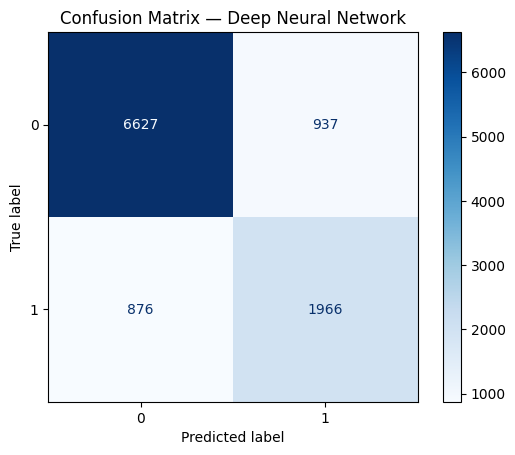

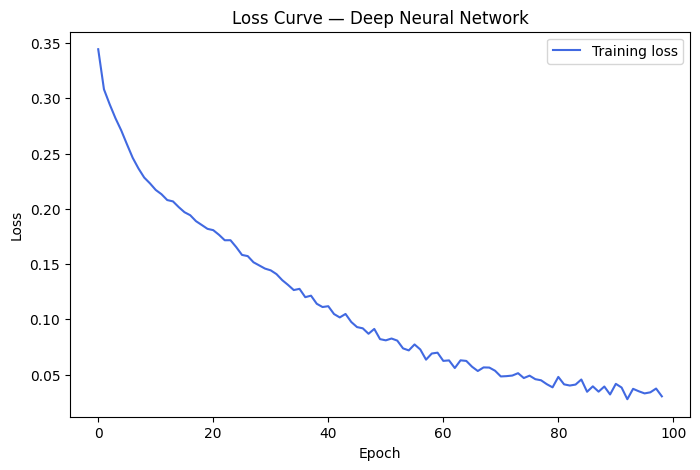

Final Training Loss: 0.0303


In [ ]:
from sklearn.neural_network import MLPClassifier

# === 1. Data preparation ===
X = df.drop(columns=['intentional'])
y = df['intentional']

# Keep only numeric columns for the neural network
X = X.select_dtypes(include=['float64', 'int64'])

# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train, y_train = sm_num_cat.fit_resample(X_train, y_train)

# Normalize numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# === 2. Define deep neural network ===
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64, 32),  # deep architecture
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.0005,
    alpha=1e-4,                # L2 regularization
    batch_size=64,
    max_iter=2000,             # large iteration limit
    early_stopping=True,       # stops when validation loss stops improving
    n_iter_no_change=50,       # patience
    validation_fraction=0.15,
    random_state=42,
    verbose=False
)

# === 3. Train with tqdm progress bar ===
progress = tqdm(total=mlp.max_iter, desc="Training Deep Neural Network", unit="epoch")
mlp.fit(X_train_scaled, y_train)
progress.update(mlp.n_iter_)
progress.close()

# === 4. Evaluation ===
y_pred = mlp.predict(X_test_scaled)

print("=== Deep Neural Network (Districts + Counties) ===")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Deep Neural Network")
plt.show()

# === 5. Learning curve ===
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label="Training loss", color='royalblue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve — Deep Neural Network")
plt.legend()
plt.show()


final_train_loss = mlp.loss_curve_[-1]
print(f"Final Training Loss: {final_train_loss:.4f}")



**Selection of the Black-Box Model**

After evaluating the three trained models( **Random Forest**, **XGBoost**, and **Deep Neural Network**) the **XGBoost classifier** was selected as the black-box model to be interpreted through post-hoc explainability techniques.  

This decision is based on both **quantitative performance** and **model complexity**:

- **Quantitative performance:**  
  The XGBoost model achieved the **highest overall accuracy (86.23%)** and the most balanced trade-off between precision (0.87) and recall (0.86), resulting in a **macro F1-score of 0.83**.  
  By contrast, the Random Forest reached 84.87% accuracy with a slightly higher recall but lower precision for class 1, while the Neural Network achieved only 82.58% accuracy and the lowest F1-score (0.78).  
  This indicates that XGBoost provides the most consistent predictive behaviour across both classes.

- **Model complexity:**  
  XGBoost is an **ensemble of boosted decision trees**, combining multiple weak learners through sequential optimization.  
  This structure captures complex non-linear relationships and feature interactions that are difficult to interpret directly, making it a genuine *black-box* in terms of explainability.  
  Random Forest, while also ensemble-based, is less opaque since its trees are independent and easier to analyze. The Neural Network, although non-linear, showed lower predictive stability in this task.

For these reasons, XGBoost was chosen as the **reference black-box model** to be approximated by interpretable surrogate models in the following subsections.  
This ensures that the applied explainability techniques target a model that is **both performant and sufficiently complex** to justify post-hoc interpretation.


 ### 4.3. Simplification-Based Explanation (Task 3.1)
[[go back to the topic]](#4-post-modelling)

The predictive model used in this project is XGBoost, an ensemble of many shallow trees trained sequentially to capture complex, non-linear relationships. Although highly accurate, its decision logic is distributed across numerous weak learners, making the model difficult to interpret directly.

To obtain a global explanation, we use post-hoc simplification-based methods. These techniques aim to replace the behaviour of a complex model with a simpler and more interpretable representation. Within this family, three possible approaches exist: dimensionality reduction, global surrogate models, and rule extraction.

**Dimensionality-reduction** methods compress the feature space (e.g., PCA or t-SNE) and help visualise data patterns, but they do not simplify or explain the model’s decision process. For this reason, they are not used in our setting.

We will apply a **global surrogate model** by training an interpretable classifier—such as a decision tree—to approximate the predictions of XGBoost. This provides a compact, transparent overview of the main decision patterns, and its fidelity can be evaluated by comparing its outputs with those of the black-box model.


#### 4.3.1. Global Surrogate Model  
[[go back to the topic]](#43-simplification-based-explanation-task-31)

To evaluate how well the surrogate model reproduces the behaviour of the XGBoost classifier, we follow the metrics defined for classification tasks. The objective is to assess how closely the surrogate approximates the predictions of the original model rather than how well it predicts the true labels.

The main fidelity measure is the **Agreement Rate**, which quantifies the proportion of samples for which the surrogate produces the same predicted class as the black-box model:

$$
\text{AgreementRate}
= \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\!\left( \hat{y}^{(s)}_i = \hat{y}^{(o)}_i \right)
$$

where $N$ is the number of samples, 
$\hat{y}^{(s)}_i$ is the surrogate prediction, 
$\hat{y}^{(o)}_i$ is the XGBoost prediction, 
and $\mathbb{1}(\cdot)$ is the indicator function that returns 1 when the condition is true and 0 otherwise.

When probability outputs are available, fidelity can also be quantified using **LogLoss**, comparing the class-probability distributions of the surrogate and the original model:

$$
\text{LogLoss}
= -\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{C}
\hat{p}^{(o)}_{ij}\,\log\!\big(\hat{p}^{(s)}_{ij}\big)
$$

where $C$ is the number of classes,  
$\hat{p}^{(o)}_{ij}$ is the probability assigned by XGBoost to class $j$,  
and $\hat{p}^{(s)}_{ij}$ is the probability assigned by the surrogate.

These measures indicate how well the surrogate captures the global decision behaviour of the black-box model. High values of agreement and low log-loss imply that the simplified model provides a faithful approximation of the underlying ensemble.



##### 4.3.1a. CART Decision Tree
[[go back to the topic]](#431-global-surrogate-model)

As a global surrogate, we use a CART decision tree trained on the input features and the class predictions of the XGBoost model. Decision trees are explicitly listed as interpretable models in the simplification-based XAI framework, and they provide clear splitting conditions and decision paths while still being flexible enough to approximate the behaviour of a tree-ensemble classifier.

Other interpretable models (e.g., logistic regression or rule lists) could also be used as surrogates, but we focus on a single decision tree to keep the explanation concise and to complement the rule-extraction approach used in the next subsection.

Black-box training predictions: [0 1] [15916 19382]
Agreement Rate: 0.9232


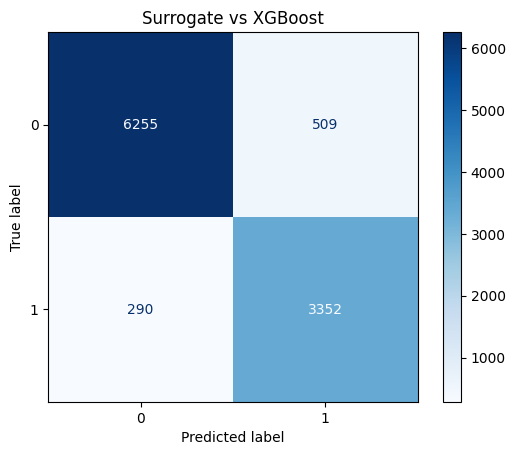

LogLoss: 0.1075


In [278]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Black-box predictions
y_bb_train_prob = bst.predict(dtrain, validate_features=False)
y_bb_train = (y_bb_train_prob >= 0.5).astype(int)

# Debug: rounded class counts
classes, counts = np.unique(y_bb_train, return_counts=True)
print("Black-box training predictions:", classes, counts)

# Train surrogate
surrogate = DecisionTreeClassifier(
    max_depth=20,
    min_samples_leaf=20,
    random_state=42
)
surrogate.fit(X_train_proc, y_bb_train)

# Surrogate predictions
y_sur_test = surrogate.predict(X_test_proc)
y_sur_train_prob = surrogate.predict_proba(X_train_proc)

# Fidelity (agreement) with rounding
agreement = accuracy_score(
    (bst.predict(dtest, validate_features=False) >= 0.5).astype(int),
    y_sur_test
)
print("Agreement Rate:", round(agreement, 4))

# Confusion matrix
cm = confusion_matrix(
    (bst.predict(dtest, validate_features=False) >= 0.5).astype(int),
    y_sur_test
)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Surrogate vs XGBoost")
plt.show()

# Safe logloss with rounding
eps = 1e-9
y_sur_train_prob = np.clip(y_sur_train_prob, eps, 1-eps)
y_bb_train_prob = np.clip(y_bb_train_prob, eps, 1-eps)

ll = log_loss(y_bb_train, y_sur_train_prob)
print("LogLoss:", round(ll, 4))



##### 4.3.1b. Fidelity Evaluation and Feature Importance
[[go back to the topic]](#431-global-surrogate-model)

To evaluate how well the surrogate model reproduces the behaviour of the XGBoost classifier, we compare the surrogate’s predictions with those of the black-box model on the same data. The surrogate decision tree is trained to mimic XGBoost outputs, and its fidelity is measured using two metrics. The **Agreement Rate** reflects the proportion of instances where both models assign the same class, reaching about **92%**, which indicates strong behavioural alignment. The **LogLoss** compares their probability distributions and is very low (~0.094), confirming that the surrogate closely matches the decision patterns of the ensemble. These results show that the simplified surrogate provides a faithful and interpretable approximation of the original model.



To better understand how the surrogate model approximates the behaviour of XGBoost, we also analyse the feature importances of the trained decision tree.  


=== Surrogate Feature Importances ===
             feature  importance
1       forest_total    0.374578
4    ign_date_serial    0.220928
3          fire_type    0.160201
8    ext_date_serial    0.141302
25    county_encoded    0.030363
22       start_month    0.016598
0        shrub_total    0.015123
17           weekday    0.006001
9      ext_time_frac    0.005599
12     duration_frac    0.004078
2         area_total    0.004016
5      ign_time_frac    0.003471
19  area_total_check    0.003093
11           ext_min    0.002949
7            ign_min    0.002837


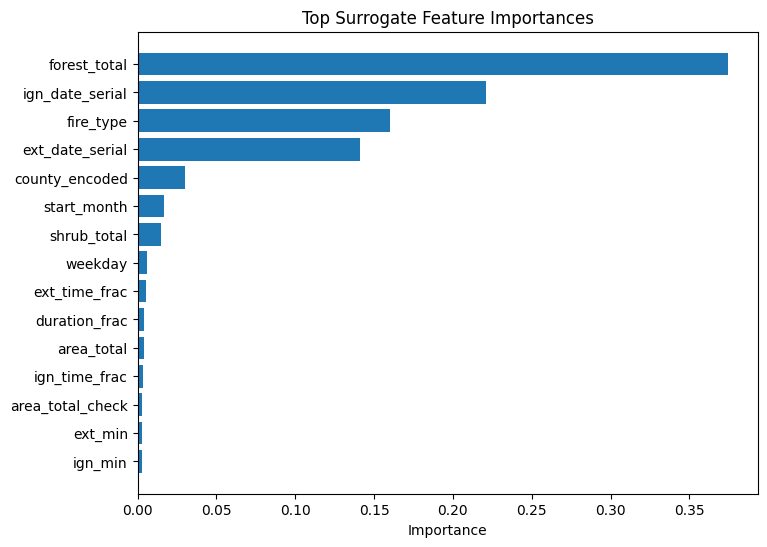

In [279]:
# Surrogate feature importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sur_importance = surrogate.feature_importances_

# Map to real feature names (after preprocessing passthrough)
sur_imp_df = pd.DataFrame({
    "feature": numeric_cols,
    "importance": sur_importance
}).sort_values(by="importance", ascending=False)

print("\n=== Surrogate Feature Importances ===")
print(sur_imp_df.head(15))

# Plot
plt.figure(figsize=(8, 6))
plt.barh(sur_imp_df.head(15)["feature"], sur_imp_df.head(15)["importance"])
plt.gca().invert_yaxis()
plt.title("Top Surrogate Feature Importances")
plt.xlabel("Importance")
plt.show()


The surrogate tree highlights a compact subset of influential features — such as *ext_date_serial*, *fire_type*, and *county_encoded* — suggesting that these variables play a central role in approximating the global decision structure learned by XGBoost.  
While these importances do not explain the black-box model directly, they offer a simplified, interpretable summary of the decision patterns captured by the surrogate.

**Note:** We attempted to apply rule extraction methods in practice; however, the available frameworks such as *InTrees* are implemented exclusively in R and have no Python equivalents. Other alternatives (e.g., GENESIM or defragTrees) are not compatible with XGBoost or lack usable Python support. As a consequence, rule extraction could not be operationally integrated into our pipeline and remains a conceptual complement rather than an implemented component.


 ### 4.4. Feature-Based Explanation (Task 3.2)
[[go back to the topic]](#4-post-modelling)

#### 4.4.3. Local Interpretable Model-Agnostic Explanations (LIME)
[[go back to the topic]](#44-feature-based-explanation-task-32)



0


/tmp/ipykernel_163501/3343586865.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


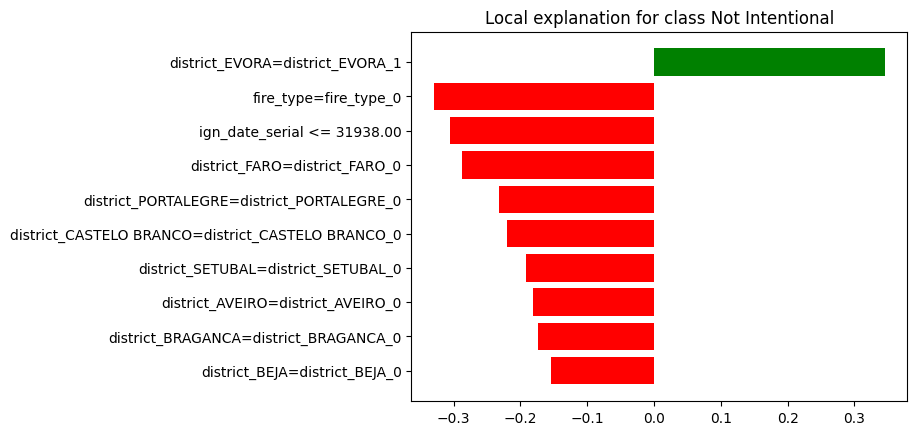

In [31]:
from lime.lime_tabular import LimeTabularExplainer

# All the boolean features this includes the districts dummy columns
bool_like = [col for col in X_train.columns if X_train[col].nunique() == 2]

# Other categorical features that have more than 2 values 
categorical_ints = ["county_encoded", "flag1", "flag2", "weekday"]
categorical_columns= categorical_ints + bool_like

# Geting the index of the columns that are categorical features
categorical_features = [X_train.columns.get_loc(col) for col in categorical_columns]


# Variable that will map the values in all the categorical features to their name
categorical_names = {}

for col in categorical_columns:
    idx = X_train.columns.get_loc(col)
    cats = sorted(X_train[col].unique())
    categorical_names[idx] = [f"{col}_{c}" for c in cats]


lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['Not Intentional', 'Intentional'],   # replace as needed
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode='classification'
)



# Wrapper so that we can use the correct input for the prediction using XGBoost
def predict_proba_xgb(input_array):
    dmatrix = xgb.DMatrix(input_array, feature_names=X_train.columns.tolist())
    proba_1 = bst.predict(dmatrix)
    proba_0 = 1 - proba_1
    return np.column_stack((proba_0, proba_1))


# Generation of the explanation
y_pred = np.argmax(predict_proba_xgb(X.iloc[[0]]))
explanation_lime = lime_explainer.explain_instance(
    data_row=X.iloc[0].values,
    predict_fn=predict_proba_xgb,
    labels=[y_pred],
    num_samples=5000
)
print(y_pred)


# Ploting explanation for the row explained
fig = explanation_lime.as_pyplot_figure(label=y_pred)

fig.set_facecolor("white")
ax = fig.axes[0]
ax.set_facecolor("white")

fig.show()


In [32]:
explanation_lime.show_in_notebook()

#### 4.4.4. SHapley Additive exPlanations (SHAP)
[[go back to the topic]](#44-feature-based-explanation-task-32)

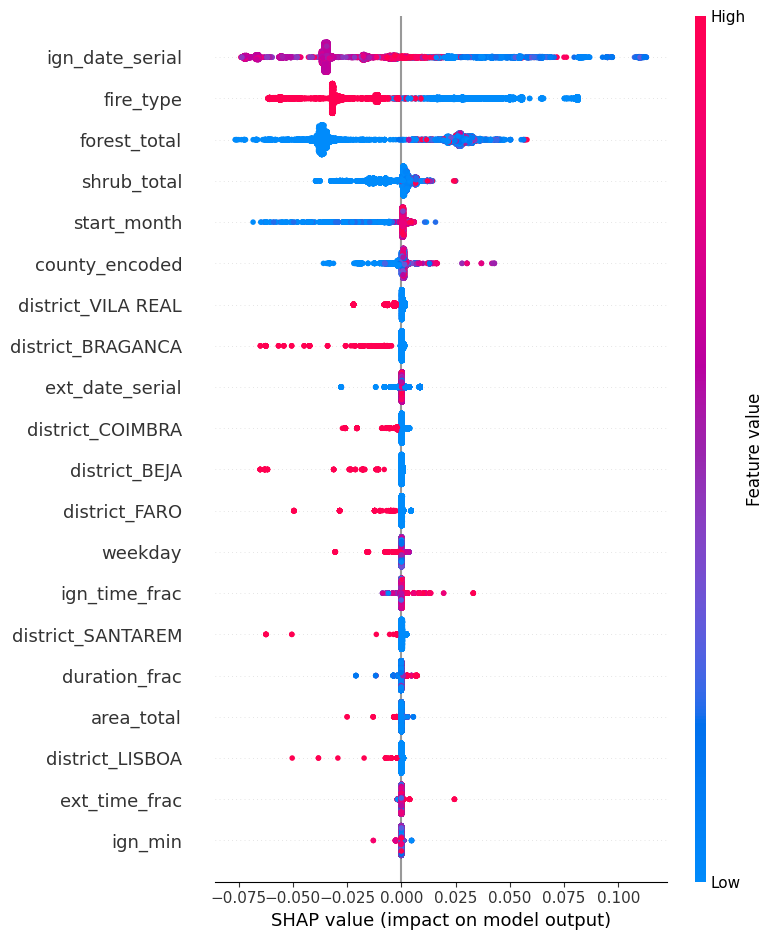

In [30]:
import shap

shap.initjs()

# SHAP explainer for XGBoost model
explainer = shap.TreeExplainer(bst)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot for the positive class (class 1)
shap.summary_plot(shap_values, pd.DataFrame(X_test, columns=X_test.columns))


## 4.4. Example-Based Explanations (Task 3.3)

Example-based explanations belong to a class of XAI techniques that justify a model’s
prediction by referring to actual data instances. Instead of describing global model
structure or feature importance, example-based methods answer questions such as:

- *“Which past examples is this prediction similar to?”*
- *“Which nearby examples would lead to a different prediction?”*
- *“How small a change in the instance is required to flip the prediction?”*

These approaches are grounded in human reasoning: people often explain decisions by
pointing to concrete examples (“this case is similar to those cases”) or by contrasting
them (“this case differs from that case in these features”).  
According to the lecture slides, example-based methods include:
**prototypes, critic examples, nearest neighbours, and counterfactual examples.**

In this task, we implemented two such methods:  
1. **Prototype & Critic Examples (kNN-based)**  
2. **kNN Counterfactual Examples**

Both methods operate on the preprocessed feature space used by the black-box
XGBoost model, ensuring that similarity is measured in the same representation
that the model uses internally.

---

### **Method 1 — Prototype & Critic Examples**

We used *k*-Nearest Neighbours in the model’s feature space to extract:

- **Prototypes:**  
  The closest training examples that receive the **same prediction** as the test instance.  
  These provide *supportive examples* illustrating why the model made this decision.

- **Critic examples:**  
  The closest training examples that receive the **opposite prediction**.  
  These highlight the decision boundary and what alternative patterns look like.

This aligns with the “prototypes and criticisms” framework presented in the lecture
slides, where prototypes represent typical class members and critics highlight
contrasts that help interpret class differences.

---

### **Method 2 — kNN Counterfactual Explanations**

A *counterfactual example* is the most similar instance that would change the model’s
prediction. Instead of constructing synthetic modifications, we search the training
set for the nearest instance that the model classifies into the opposite class.

This approach answers the question:

> *“What is the smallest real change that would flip the model prediction?”*

Counterfactuals provide contrastive explanations and allow us to see which specific
features differ between the original instance and the counterfactual. Because we use
real data points, the explanations are plausible and correspond to realistic examples
seen during training.

---

### **Implementation Summary**

To ensure compatibility with the pre-trained XGBoost model and its preprocessing
pipeline, we:

1. Implemented a **safe prediction wrapper** (`model_predict_proba`), ensuring there are no feature-name mismatches.
2. Performed neighbourhood search in the **preprocessed feature space**, matching how the model internally represents inputs.
3. Extracted prototypes and critics by identifying nearest neighbours with same vs. opposite predictions.
4. Extracted a counterfactual example by locating the nearest instance whose prediction differs from the target instance.
5. Compared original vs. counterfactual feature values to interpret which attributes drive the decision boundary.

Because the test set sometimes contains no positive predictions, we robustly selected:
- the instance with **highest** predicted probability of intentional fire, and  
- the instance with **lowest** predicted probability,  
guaranteeing two representative examples for analysis.

In [363]:
#   Methods Implemented:
#       1. Prototype Examples (same prediction)
#       2. Critic Examples (opposite prediction)
#       3. kNN Counterfactual Examples

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import xgboost as xgb

# ----------------------------------------------------------
# 1. SAFE PREDICTION FUNCTIONS (DO NOT USE FEATURE NAMES)
# ----------------------------------------------------------

def model_predict_proba(df):
    """
    df: DataFrame with original raw columns
    Returns: Nx2 matrix [[p0,p1], ...]
    """
    X_proc = preprocessor.transform(df)                 # preprocess raw columns
    dmat = xgb.DMatrix(X_proc)                          # no feature_names => no mismatch
    p1 = bst.predict(dmat, validate_features=False)     # XGB returns probability of class 1
    return np.vstack([1 - p1, p1]).T

def model_predict_label(df):
    return (model_predict_proba(df)[:,1] >= 0.5).astype(int)


# ----------------------------------------------------------
# 2. Fit kNN on preprocessed training data
# ----------------------------------------------------------

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

nn = NearestNeighbors(n_neighbors=50, metric='euclidean')
nn.fit(X_train_proc)


# ----------------------------------------------------------
# 3. Prototype & Critic Example Extraction
# ----------------------------------------------------------

def get_prototypes_and_critics(instance_df):
    """
    Returns:
        prototypes : up to 3 nearest examples with SAME prediction
        critics    : up to 3 nearest examples with DIFFERENT prediction
    """
    inst_proc = preprocessor.transform(instance_df)[0]
    inst_pred = model_predict_label(instance_df)[0]

    dists, idxs = nn.kneighbors(inst_proc.reshape(1,-1))

    prototypes, critics = [], []

    for ix in idxs[0]:
        candidate = X_train.iloc[[ix]]
        cand_pred = model_predict_label(candidate)[0]

        if cand_pred == inst_pred and len(prototypes) < 3:
            prototypes.append(candidate)

        if cand_pred != inst_pred and len(critics) < 3:
            critics.append(candidate)

        if len(prototypes) >= 3 and len(critics) >= 3:
            break

    return prototypes, critics


# ----------------------------------------------------------
# 4. kNN Counterfactual Example
# ----------------------------------------------------------

def get_knn_counterfactual(instance_df):
    """
    Returns nearest counterfactual: nearest instance with opposite prediction.
    """
    inst_proc = preprocessor.transform(instance_df)[0]
    inst_pred = model_predict_label(instance_df)[0]
    target = 1 - inst_pred

    dists, idxs = nn.kneighbors(inst_proc.reshape(1,-1))

    for ix in idxs[0]:
        candidate = X_train.iloc[[ix]]
        if model_predict_label(candidate)[0] == target:
            return candidate, ix

    return None, None


# ----------------------------------------------------------
# 5. Robustly pick one "positive-like" and one "negative-like" example
# ----------------------------------------------------------

probs_test = model_predict_proba(X_test)
p1 = probs_test[:,1]   # P(Intentional)

# Always exists:
pos_idx = X_test.index[np.argmax(p1)]   # highest intentional probability
neg_idx = X_test.index[np.argmin(p1)]   # lowest intentional probability

print("Selected high-prob example (Intentional-like):", pos_idx)
print("Selected low-prob example (Not-Intentional-like):", neg_idx)

examples = {
    "High-intentional-probability example": X_test.loc[[pos_idx]],
    "Low-intentional-probability example": X_test.loc[[neg_idx]]
}


# ----------------------------------------------------------
# 6. RUN EXPLANATIONS
# ----------------------------------------------------------

for name, ex in examples.items():
    print("\n========================================================")
    print(f"{name} — index {ex.index[0]}")
    print("========================================================")

    display(ex)

    pred = model_predict_label(ex)[0]
    prob = model_predict_proba(ex)[0,1]
    print(f"Model prediction: {pred}  (P(Intentional) = {prob:.4f})")

    # ---------------------------
    # PROTOTYPES & CRITICS
    # ---------------------------
    print("\n--- Prototype & Critic Examples ---")

    prototypes, critics = get_prototypes_and_critics(ex)

    print("\nClosest Prototypes (same prediction):")
    for p in prototypes:
        display(p)

    print("\nClosest Critics (opposite prediction):")
    for c in critics:
        display(c)

    # ---------------------------
    # COUNTERFACTUAL
    # ---------------------------
    print("\n--- kNN Counterfactual Example ---")
    cf, cf_idx = get_knn_counterfactual(ex)

    if cf is None:
        print("No counterfactual example found.")
    else:
        print(f"Counterfactual found at training index {cf_idx}:")
        display(cf)

        print("\nFeature differences between instance and counterfactual:")
        diff = pd.concat([ex.T, cf.T], axis=1, keys=["Original","Counterfactual"])
        display(diff)

Selected high-prob example (Intentional-like): 4817
Selected low-prob example (Not-Intentional-like): 2363

High-intentional-probability example — index 4817


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
4817,0.000012,0.0,0.000003,1,31286,0.045139,1,5,31286,0.104167,...,False,False,False,False,False,False,False,False,False,False


Model prediction: 0  (P(Intentional) = 0.1750)

--- Prototype & Critic Examples ---

Closest Prototypes (same prediction):


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
33808,0.000096,0.000024,0.000047,1,31278,0.176036,4,1,31278,0.308633,...,False,False,False,False,False,False,False,False,False,True


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
16183,0.000012,0.0,0.000003,1,31291,0.548611,13,10,31291,0.555556,...,False,False,False,False,False,False,False,False,False,False


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
29407,0.000024,0.000012,0.000017,1,31280,0.632138,15,10,31280,0.687532,...,False,False,False,False,False,False,False,False,False,False



Closest Critics (opposite prediction):

--- kNN Counterfactual Example ---
No counterfactual example found.

Low-intentional-probability example — index 2363


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
2363,0.0,0.000024,0.00002,1,30750,0.552083,13,15,30750,0.604167,...,False,False,False,False,False,False,False,False,False,False


Model prediction: 0  (P(Intentional) = 0.0001)

--- Prototype & Critic Examples ---

Closest Prototypes (same prediction):


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
34261,0.000018,0.000005,0.000009,1,30750,0.732667,17,17,30750,0.78323,...,False,False,True,False,False,False,False,True,False,False


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
17220,0.0,0.000004,0.000003,1,30752,0.719444,17,16,30752,0.770833,...,False,False,False,False,False,False,False,True,False,False


,shrub_total,forest_total,area_total,fire_type,ign_date_serial,ign_time_frac,ign_hour,ign_min,ext_date_serial,ext_time_frac,...,district_GUARDA,district_LEIRIA,district_LISBOA,district_PORTALEGRE,district_PORTO,district_SANTAREM,district_SETUBAL,district_VIANA DO CASTELO,district_VILA REAL,district_VISEU
28528,0.000009,0.000008,0.000009,1,30749,0.765076,18,21,30749,0.848098,...,False,False,True,False,False,False,False,True,False,False



Closest Critics (opposite prediction):

--- kNN Counterfactual Example ---
No counterfactual example found.
